# Evaluation
**Proyek:** Pothole Detection System

Notebook ini mengevaluasi **semua eksperimen** pada test set dan membandingkan hasilnya.

1. Setup
2. Load & Evaluasi Semua Model
3. Tabel Perbandingan
4. Confusion Matrix (Best Model)
5. ROC Curve (Semua Model)
6. Error Analysis (Best Model)
7. Ringkasan

---
## Setup

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

ROOT      = Path("../").resolve()
PROC_DIR  = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES     = ["normal", "potholes"]
NUM_CLASSES = 2
BATCH_SIZE  = 32

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_ds     = datasets.ImageFolder(PROC_DIR / "test", transform=transform_test)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test set : {len(test_ds)} gambar | class_to_idx: {test_ds.class_to_idx}")

Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Ti
Test set : 103 gambar | class_to_idx: {'normal': 0, 'potholes': 1}


---
## Baseline Model (Majority Classifier)

In [37]:
# Hitung label test set
y_true_all  = np.array([label for _, label in test_ds.samples])

# Mayoritas kelas di test set
majority_class = int(np.bincount(y_true_all).argmax())
y_pred_baseline = np.full_like(y_true_all, majority_class)
y_prob_baseline = np.where(y_true_all == 1, 0.0, 1.0).astype(float)  # prob potholes = 0

rec_per_class_bl = recall_score(y_true_all, y_pred_baseline, average=None, zero_division=0)

baseline_metrics = {
    "acc":          accuracy_score(y_true_all, y_pred_baseline),
    "precision":    precision_score(y_true_all, y_pred_baseline, average="macro", zero_division=0),
    "recall":       recall_score(y_true_all, y_pred_baseline, average="macro", zero_division=0),
    "f1":           f1_score(y_true_all, y_pred_baseline, average="macro", zero_division=0),
    "rec_normal":   rec_per_class_bl[0] if len(rec_per_class_bl) > 0 else 0.0,
    "rec_potholes": rec_per_class_bl[1] if len(rec_per_class_bl) > 1 else 0.0,
    "auc":          0.5,   # random classifier AUC
    "y_true":       y_true_all,
    "y_pred":       y_pred_baseline,
    "y_prob":       y_prob_baseline,
}

print(f"Majority class   : {CLASSES[majority_class]}")
print(f"Accuracy         : {baseline_metrics['acc']:.4f}")
print(f"Precision (macro): {baseline_metrics['precision']:.4f}")
print(f"Recall (macro)   : {baseline_metrics['recall']:.4f}")
print(f"F1-macro         : {baseline_metrics['f1']:.4f}")
print(f"Recall Normal    : {baseline_metrics['rec_normal']:.4f}")
print(f"Recall Potholes  : {baseline_metrics['rec_potholes']:.4f}")
print(f"ROC-AUC          : {baseline_metrics['auc']:.4f}  (random baseline)")
print(f"\nClassification Report:")
print(classification_report(y_true_all, y_pred_baseline, target_names=CLASSES))

Majority class   : normal
Accuracy         : 0.5146
Precision (macro): 0.2573
Recall (macro)   : 0.5000
F1-macro         : 0.3397
Recall Normal    : 1.0000
Recall Potholes  : 0.0000
ROC-AUC          : 0.5000  (random baseline)

Classification Report:
              precision    recall  f1-score   support

      normal       0.51      1.00      0.68        53
    potholes       0.00      0.00      0.00        50

    accuracy                           0.51       103
   macro avg       0.26      0.50      0.34       103
weighted avg       0.26      0.51      0.35       103



m:\final_dbb\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
m:\final_dbb\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
m:\final_dbb\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---
## Definisi Model & Fungsi Evaluasi

In [38]:
def build_model(arch: str) -> nn.Module:
    if arch == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    elif arch == "resnet18":
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif arch == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, NUM_CLASSES)
    elif arch == "vit_tiny":
        m = timm.create_model(
            "vit_tiny_patch16_224.augreg_in21k_ft_in1k",
            pretrained=False, num_classes=NUM_CLASSES
        )
    else:
        raise ValueError(f"Unknown arch: {arch}")
    return m.to(DEVICE)


@torch.no_grad()
def evaluate_model(model):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        prob = torch.softmax(out, dim=1)[:, 1]
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(prob.cpu().numpy())
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    return {
        "acc":          accuracy_score(y_true, y_pred),
        "precision":    precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":       recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":           f1_score(y_true, y_pred, average="macro", zero_division=0),
        "rec_normal":   rec_per_class[0] if len(rec_per_class) > 0 else 0.0,
        "rec_potholes": rec_per_class[1] if len(rec_per_class) > 1 else 0.0,
        "auc":          roc_auc_score(y_true, y_prob),
        "y_true":       y_true,
        "y_pred":       y_pred,
        "y_prob":       y_prob,
    }


# Eksperimen -> arsitektur
EXP_CONFIG = {
    "Exp1: EffNet frozen":    "efficientnet_b0",
    "Exp2: EffNet fine-tune": "efficientnet_b0",
    "Exp3: EffNet+scheduler": "efficientnet_b0",
    "Exp4: MobileNetV3":      "mobilenet_v3_small",
    "Exp5: ResNet18":         "resnet18",
    "Exp6: ViT-Tiny":         "vit_tiny",
}

print("Helper siap.")

Helper siap.


---
## Load & Evaluasi Semua Model

In [39]:
# Mulai dengan baseline
eval_results  = {"Baseline (Majority)": baseline_metrics}
loaded_models = {}

# Scan semua file .pth
pth_files = sorted(MODEL_DIR.glob("*.pth"))
print(f"File .pth ditemukan: {[f.name for f in pth_files]}\n")

for pth_path in pth_files:
    ckpt     = torch.load(pth_path, map_location=DEVICE, weights_only=False)
    exp_name = ckpt.get("experiment", pth_path.stem)
    arch     = EXP_CONFIG.get(exp_name, "efficientnet_b0")

    model = build_model(arch)
    model.load_state_dict(ckpt["model_state_dict"])

    metrics = evaluate_model(model)
    eval_results[exp_name]  = metrics
    loaded_models[exp_name] = model

    print(f"[{exp_name}]")
    print(f"  Acc={metrics['acc']:.4f} | Prec={metrics['precision']:.4f} | "
          f"Rec={metrics['recall']:.4f} | F1={metrics['f1']:.4f} | "
          f"AUC={metrics['auc']:.4f}")
    print(f"  Recall Normal={metrics['rec_normal']:.4f} | Recall Potholes={metrics['rec_potholes']:.4f}")
    torch.cuda.empty_cache()

print(f"\nTotal model dievaluasi: {len(eval_results)} (termasuk baseline)")

File .pth ditemukan: ['best_model.pth', 'exp1_effnet_frozen.pth', 'exp2_effnet_finetune.pth', 'exp3_effnet_scheduler.pth', 'exp4_mobilenetv3.pth', 'exp5_resnet18.pth', 'exp6_vit_tiny.pth']

[Exp1: EffNet frozen]
  Acc=0.9515 | Prec=0.9518 | Rec=0.9511 | F1=0.9514 | AUC=0.9936
  Recall Normal=0.9623 | Recall Potholes=0.9400
[Exp1: EffNet frozen]
  Acc=0.9515 | Prec=0.9518 | Rec=0.9511 | F1=0.9514 | AUC=0.9936
  Recall Normal=0.9623 | Recall Potholes=0.9400
[Exp2: EffNet fine-tune]
  Acc=0.9903 | Prec=0.9902 | Rec=0.9906 | F1=0.9903 | AUC=1.0000
  Recall Normal=0.9811 | Recall Potholes=1.0000
[Exp3: EffNet+scheduler]
  Acc=0.9709 | Prec=0.9713 | Rec=0.9706 | F1=0.9708 | AUC=0.9951
  Recall Normal=0.9811 | Recall Potholes=0.9600
[Exp4: MobileNetV3]
  Acc=0.9515 | Prec=0.9545 | Rec=0.9528 | F1=0.9514 | AUC=0.9989
  Recall Normal=0.9057 | Recall Potholes=1.0000
[Exp5: ResNet18]
  Acc=0.9806 | Prec=0.9806 | Rec=0.9806 | F1=0.9806 | AUC=0.9992
  Recall Normal=0.9811 | Recall Potholes=0.9800
[

---
## Tabel Perbandingan

In [40]:
rows = []
for exp, m in eval_results.items():
    rows.append({
        "Experiment":      exp,
        "Accuracy":        m["acc"],
        "Precision":       m["precision"],
        "Recall (macro)":  m["recall"],
        "F1-macro":        m["f1"],
        "Rec Normal":      m["rec_normal"],
        "Rec Potholes":    m["rec_potholes"],
        "ROC-AUC":         m["auc"],
    })

df_cmp = pd.DataFrame(rows).set_index("Experiment")

styled = df_cmp.style \
    .format("{:.4f}") \
    .highlight_max(axis=0, color="#d4edda") \
    .set_caption("Test Set — Perbandingan Semua Eksperimen (hijau = terbaik per kolom)")
display(styled)

,Accuracy,Precision,Recall (macro),F1-macro,Rec Normal,Rec Potholes,ROC-AUC
Experiment,,,,,,,
Baseline (Majority),0.5146,0.2573,0.5000,0.3397,1.0000,0.0000,0.5000
Exp1: EffNet frozen,0.9515,0.9518,0.9511,0.9514,0.9623,0.9400,0.9936
Exp2: EffNet fine-tune,0.9903,0.9902,0.9906,0.9903,0.9811,1.0000,1.0000
Exp3: EffNet+scheduler,0.9709,0.9713,0.9706,0.9708,0.9811,0.9600,0.9951
Exp4: MobileNetV3,0.9515,0.9545,0.9528,0.9514,0.9057,1.0000,0.9989
Exp5: ResNet18,0.9806,0.9806,0.9806,0.9806,0.9811,0.9800,0.9992
Exp6: ViT-Tiny,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Bar Chart Perbandingan

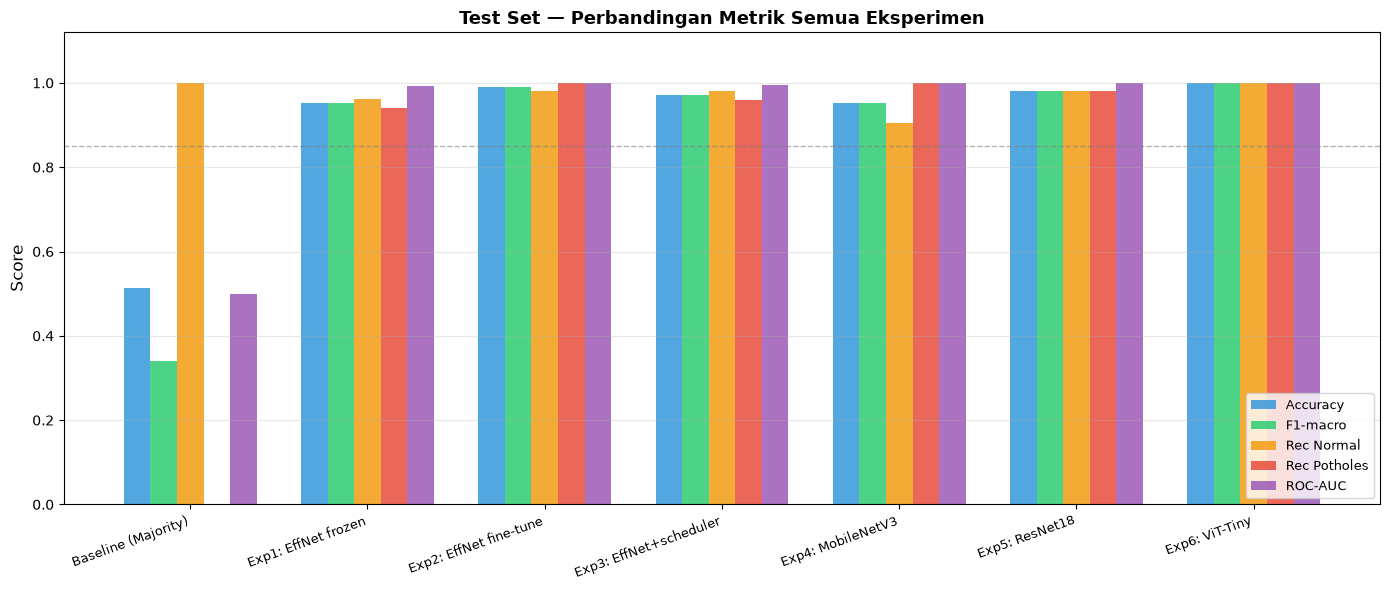

In [41]:
metrics_to_plot = ["Accuracy", "F1-macro", "Rec Normal", "Rec Potholes", "ROC-AUC"]
exp_names = df_cmp.index.tolist()
x = np.arange(len(exp_names))
width = 0.15
colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = df_cmp[metric].values
    offset = (i - len(metrics_to_plot) / 2) * width + width / 2
    bars = ax.bar(x + offset, vals, width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test Set — Perbandingan Metrik Semua Eksperimen", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.axhline(0.85, color="gray", linestyle="--", lw=1, alpha=0.6, label="Target 0.85")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eval_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Confusion Matrix — Semua Model

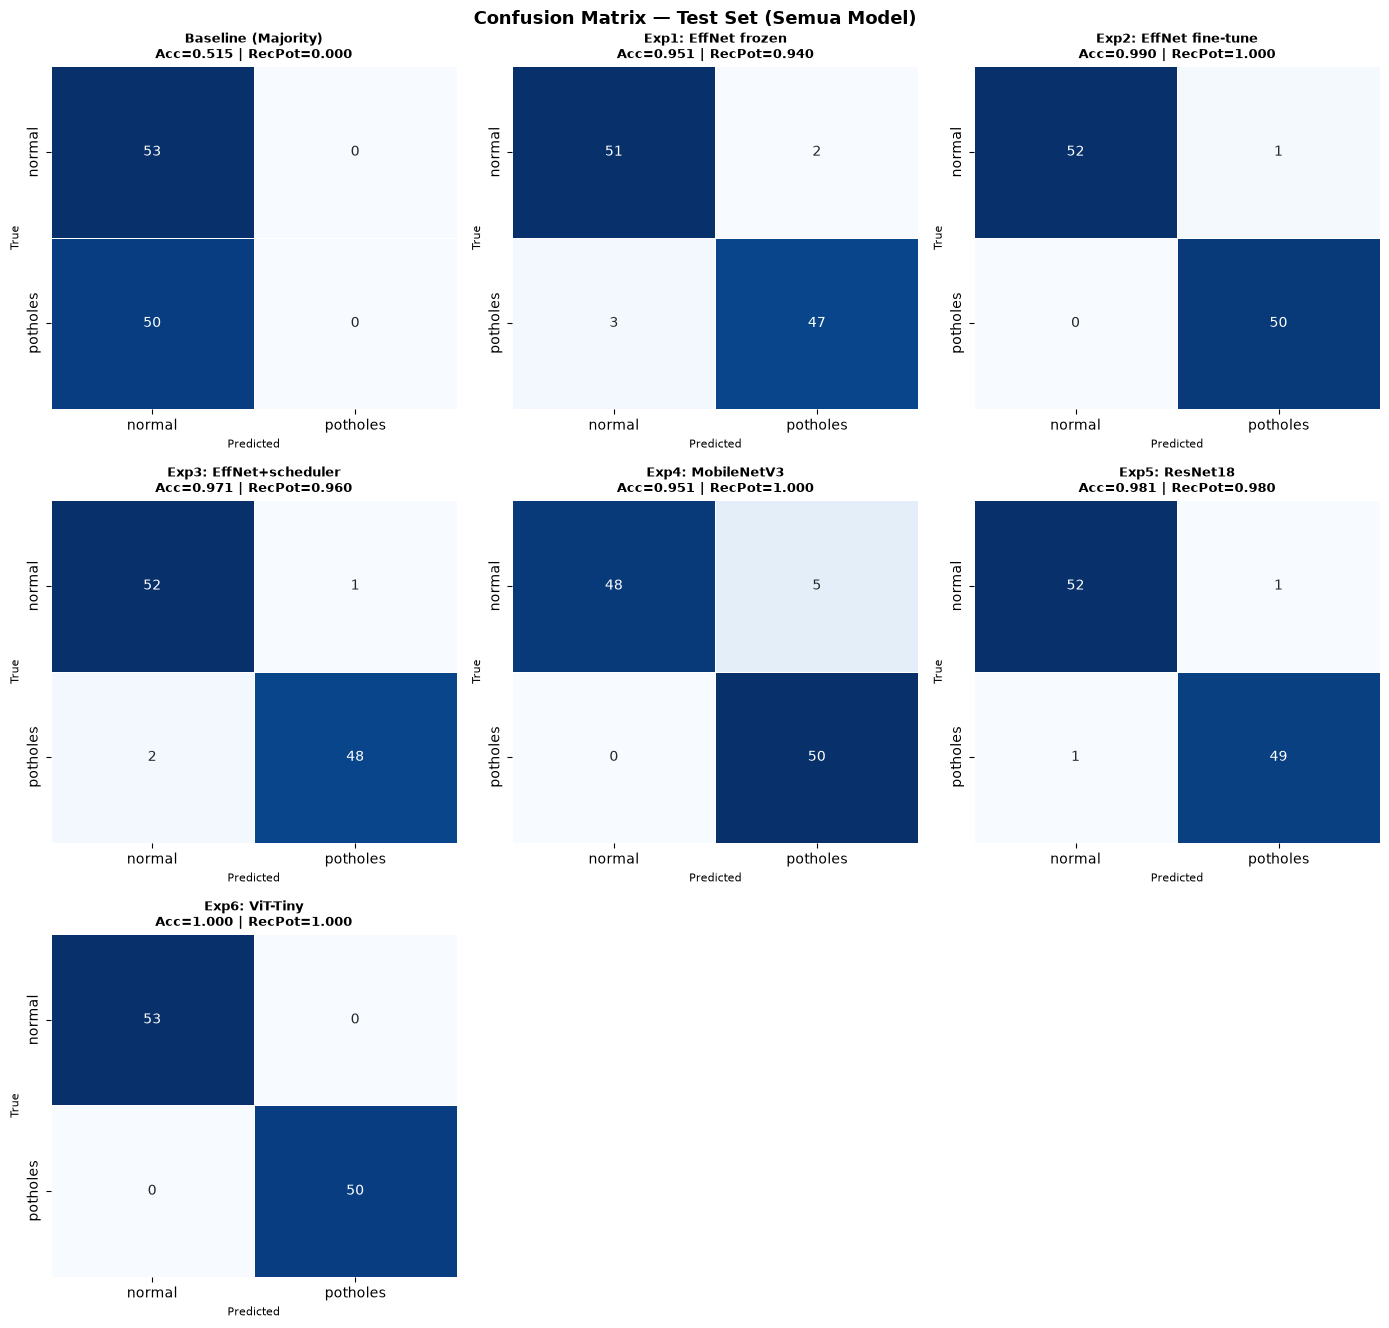

In [42]:
n_models = len(eval_results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()

for i, (exp_name, metrics) in enumerate(eval_results.items()):
    cm = confusion_matrix(metrics["y_true"], metrics["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=axes[i], cbar=False)
    acc = metrics["acc"]
    rp  = metrics["rec_potholes"]
    axes[i].set_title(f"{exp_name}\nAcc={acc:.3f} | RecPot={rp:.3f}",
                      fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Predicted", fontsize=8)
    axes[i].set_ylabel("True", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Confusion Matrix — Test Set (Semua Model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eval_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

---
## ROC Curve — Semua Model

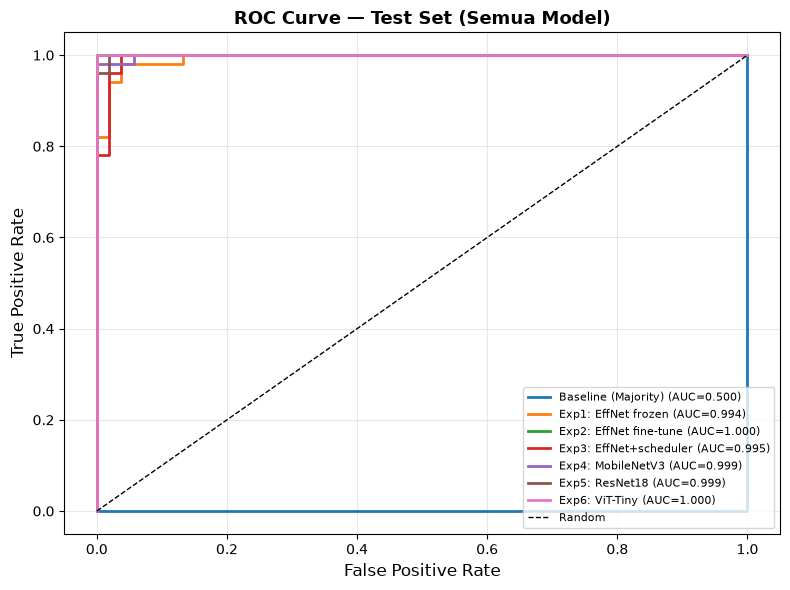

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap("tab10")

for i, (exp_name, metrics) in enumerate(eval_results.items()):
    fpr, tpr, _ = roc_curve(metrics["y_true"], metrics["y_prob"])
    auc = metrics["auc"]
    ax.plot(fpr, tpr, lw=2, color=cmap(i), label=f"{exp_name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Test Set (Semua Model)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eval_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Error Analysis — Best Model

In [44]:
metrics_best = eval_results[best_exp]
y_true  = metrics_best["y_true"]
y_pred  = metrics_best["y_pred"]
y_prob  = metrics_best["y_prob"]
paths   = [s[0] for s in test_ds.samples]

wrong_idx = np.where(y_pred != y_true)[0]
print(f"Best model    : {best_exp}")
print(f"Salah prediksi: {len(wrong_idx)} dari {len(y_true)} gambar")

# Classification report lengkap
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

n_show = min(9, len(wrong_idx))
if n_show == 0:
    print("Tidak ada kesalahan prediksi pada best model!")
else:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    for i, idx in enumerate(wrong_idx[:n_show]):
        img      = Image.open(paths[idx]).convert("RGB")
        true_lbl = CLASSES[y_true[idx]]
        pred_lbl = CLASSES[y_pred[idx]]
        conf     = y_prob[idx] if y_pred[idx] == 1 else 1 - y_prob[idx]
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})",
                          color="red", fontsize=9)
        axes[i].axis("off")
    for j in range(n_show, 9):
        axes[j].axis("off")
    plt.suptitle(f"Error Analysis — {best_exp}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(ROOT / "notebooks" / "eval_error_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()

Best model    : Exp6: ViT-Tiny
Salah prediksi: 0 dari 103 gambar

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        53
    potholes       1.00      1.00      1.00        50

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103

Tidak ada kesalahan prediksi pada best model!


---
## Ringkasan Final

In [45]:
THRESHOLD_ACC = 0.85
THRESHOLD_REC = 0.85

print("=" * 60)
print("  EVALUATION SUMMARY — Pothole Detection (Test Set)")
print("=" * 60)
print(f"\n  {'Experiment':<28} {'Acc':>6} {'F1':>6} {'RecPot':>8} {'AUC':>7} {'Status':<10}")
print(f"  {'-'*70}")

for exp, m in eval_results.items():
    status = "PASS" if m["acc"] >= THRESHOLD_ACC and m["rec_potholes"] >= THRESHOLD_REC else "REVIEW"
    marker = " <-- BEST" if exp == best_exp else ""
    print(f"  {exp:<28} {m['acc']:>6.4f} {m['f1']:>6.4f} {m['rec_potholes']:>8.4f} "
          f"{m['auc']:>7.4f}  {status}{marker}")

print(f"\n  Target   : Acc >= {THRESHOLD_ACC} | Recall Potholes >= {THRESHOLD_REC}")
print(f"  Best     : {best_exp}")
print(f"  Composite: 0.4 x F1-macro + 0.6 x Recall-potholes")
print("=" * 60)

  EVALUATION SUMMARY — Pothole Detection (Test Set)

  Experiment                      Acc     F1   RecPot     AUC Status    
  ----------------------------------------------------------------------
  Baseline (Majority)          0.5146 0.3397   0.0000  0.5000  REVIEW
  Exp1: EffNet frozen          0.9515 0.9514   0.9400  0.9936  PASS
  Exp2: EffNet fine-tune       0.9903 0.9903   1.0000  1.0000  PASS
  Exp3: EffNet+scheduler       0.9709 0.9708   0.9600  0.9951  PASS
  Exp4: MobileNetV3            0.9515 0.9514   1.0000  0.9989  PASS
  Exp5: ResNet18               0.9806 0.9806   0.9800  0.9992  PASS
  Exp6: ViT-Tiny               1.0000 1.0000   1.0000  1.0000  PASS <-- BEST

  Target   : Acc >= 0.85 | Recall Potholes >= 0.85
  Best     : Exp6: ViT-Tiny
  Composite: 0.4 x F1-macro + 0.6 x Recall-potholes


---
## Inference Time — Simulasi Deployment

In [46]:
import time

N_WARMUP = 5
N_REPEAT = 20

sample_img_path = test_ds.samples[0][0]
sample_img = Image.open(sample_img_path).convert("RGB")

transform_single = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

timing_rows = []

for exp_name, model in loaded_models.items():
    model.eval()
    tensor_single = transform_single(sample_img).unsqueeze(0).to(DEVICE)

    # Warmup
    with torch.no_grad():
        for _ in range(N_WARMUP):
            _ = model(tensor_single)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    # Single image
    times_single = []
    with torch.no_grad():
        for _ in range(N_REPEAT):
            t0 = time.perf_counter()
            _ = model(tensor_single)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times_single.append((time.perf_counter() - t0) * 1000)
    avg_single = float(np.mean(times_single))

    # Bulk 100 gambar
    tensor_bulk = tensor_single.repeat(100, 1, 1, 1)
    BULK_BATCH  = 32
    t0 = time.perf_counter()
    with torch.no_grad():
        for i in range(0, 100, BULK_BATCH):
            _ = model(tensor_bulk[i:i + BULK_BATCH])
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t_bulk = (time.perf_counter() - t0) * 1000

    timing_rows.append({
        "Experiment":         exp_name,
        "Single (ms)":        round(avg_single, 2),
        "Bulk 100 img (ms)":  round(t_bulk, 2),
        "Bulk 100 img (s)":   round(t_bulk / 1000, 3),
        "Throughput (img/s)": round(100 / (t_bulk / 1000), 1),
    })

    print(f"[{exp_name}] single={avg_single:.2f}ms | "
          f"bulk100={t_bulk:.0f}ms ({t_bulk/1000:.2f}s) | "
          f"{100/(t_bulk/1000):.1f} img/s")

df_timing = pd.DataFrame(timing_rows).set_index("Experiment")

# Best model = bulk tercepat
df_timing_models = df_timing.drop(index="Baseline (Majority)", errors="ignore")
best_exp = df_timing_models["Bulk 100 img (ms)"].idxmin()
print(f"\nBest model (bulk time terendah): {best_exp}")

styled_timing = df_timing.style \
    .format({"Single (ms)": "{:.2f}", "Bulk 100 img (ms)": "{:.1f}",
             "Bulk 100 img (s)": "{:.3f}", "Throughput (img/s)": "{:.1f}"}) \
    .highlight_min(subset=["Single (ms)", "Bulk 100 img (ms)"], color="#d4edda") \
    .highlight_max(subset=["Throughput (img/s)"], color="#d4edda") \
    .set_caption("Inference Time — Simulasi Deployment (hijau = terbaik, best_exp dari bulk terendah)")
display(styled_timing)

[Exp1: EffNet frozen] single=8.42ms | bulk100=91ms (0.09s) | 1093.5 img/s
[Exp2: EffNet fine-tune] single=7.94ms | bulk100=55ms (0.05s) | 1819.4 img/s
[Exp3: EffNet+scheduler] single=7.38ms | bulk100=56ms (0.06s) | 1801.2 img/s
[Exp4: MobileNetV3] single=5.43ms | bulk100=22ms (0.02s) | 4452.7 img/s
[Exp5: ResNet18] single=2.62ms | bulk100=39ms (0.04s) | 2555.2 img/s
[Exp6: ViT-Tiny] single=6.32ms | bulk100=41ms (0.04s) | 2426.9 img/s

Best model (bulk time terendah): Exp4: MobileNetV3


,Single (ms),Bulk 100 img (ms),Bulk 100 img (s),Throughput (img/s)
Experiment,,,,
Exp1: EffNet frozen,8.42,91.5,0.091,1093.5
Exp2: EffNet fine-tune,7.94,55.0,0.055,1819.4
Exp3: EffNet+scheduler,7.38,55.5,0.056,1801.2
Exp4: MobileNetV3,5.43,22.5,0.022,4452.7
Exp5: ResNet18,2.62,39.1,0.039,2555.2
Exp6: ViT-Tiny,6.32,41.2,0.041,2426.9


---
## Confidence Distribution & Threshold 70% (Best Model)

Best model    : Exp4: MobileNetV3
Threshold     : 70%
Auto Detected : 101 gambar  (98.1%)
Needs Review  : 2 gambar  (1.9%)


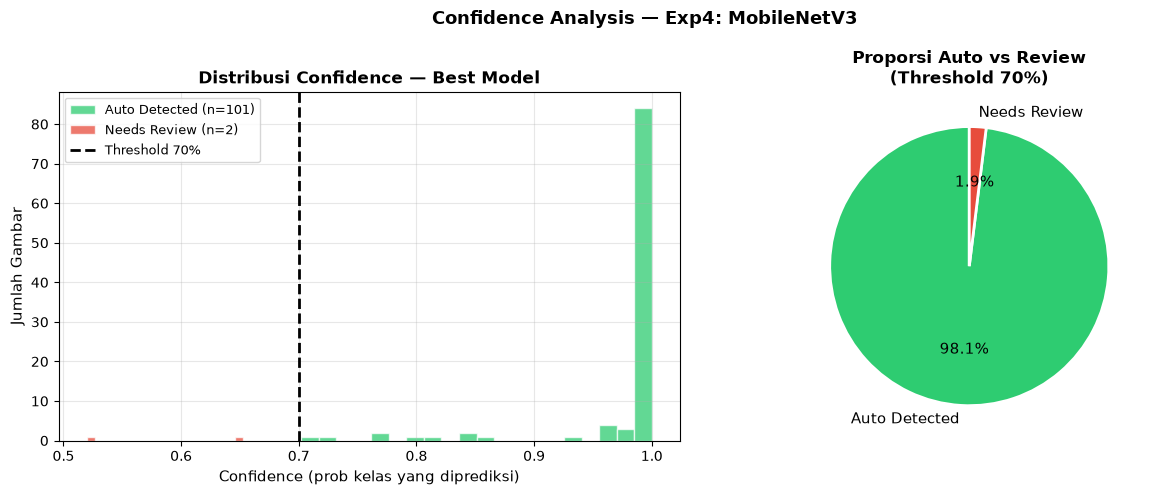


Sample tabel per gambar (10 pertama):


,filename,true_label,prediction,confidence,status,correct
0,110.jpg,normal,normal,0.9980,Auto Detected,True
1,117.jpg,normal,normal,0.9999,Auto Detected,True
2,118.jpg,normal,normal,0.9980,Auto Detected,True
3,13.jpg,normal,normal,0.9861,Auto Detected,True
4,142.jpg,normal,normal,1.0000,Auto Detected,True
5,143.jpg,normal,normal,0.9966,Auto Detected,True
6,144.jpg,normal,normal,0.9987,Auto Detected,True
7,146.jpg,normal,potholes,0.8539,Auto Detected,False
8,148.jpg,normal,normal,0.9990,Auto Detected,True
9,151.jpg,normal,normal,0.8431,Auto Detected,True


Akurasi [Auto Detected   ]: 0.9604 (101 gambar)
Akurasi [Needs Review    ]: 0.5000 (2 gambar)


In [47]:
CONFIDENCE_THRESHOLD = 0.70

# Confidence = prob kelas terpilih
best_model_obj = loaded_models[best_exp]
best_model_obj.eval()

all_confidences, all_preds_conf, all_labels_conf = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out  = best_model_obj(imgs)
        probs_all  = torch.softmax(out, dim=1)          # [batch, 2]
        pred_class = probs_all.argmax(1)                # kelas yang dipilih
        confidence = probs_all[range(len(pred_class)), pred_class]  # prob kelas tersebut

        all_confidences.extend(confidence.cpu().numpy())
        all_preds_conf.extend(pred_class.cpu().numpy())
        all_labels_conf.extend(labels.numpy())

confidences  = np.array(all_confidences)
preds_conf   = np.array(all_preds_conf)
labels_conf  = np.array(all_labels_conf)
all_paths    = [s[0] for s in test_ds.samples]

# Status berdasarkan keyakinan model terhadap prediksinya
status_flags = np.where(confidences >= CONFIDENCE_THRESHOLD, "Auto Detected", "Needs Review")

n_auto   = (status_flags == "Auto Detected").sum()
n_review = (status_flags == "Needs Review").sum()

print(f"Best model    : {best_exp}")
print(f"Threshold     : {CONFIDENCE_THRESHOLD:.0%}")
print(f"Auto Detected : {n_auto} gambar  ({n_auto/len(confidences)*100:.1f}%)")
print(f"Needs Review  : {n_review} gambar  ({n_review/len(confidences)*100:.1f}%)")

# --- Plot 1: Histogram confidence per status ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for status, color in {"Auto Detected": "#2ecc71", "Needs Review": "#e74c3c"}.items():
    mask = status_flags == status
    axes[0].hist(confidences[mask], bins=20, alpha=0.75, color=color,
                 label=f"{status} (n={mask.sum()})", edgecolor="white")

axes[0].axvline(CONFIDENCE_THRESHOLD, color="black", linestyle="--", lw=2,
                label=f"Threshold {CONFIDENCE_THRESHOLD:.0%}")
axes[0].set_xlabel("Confidence (prob kelas yang diprediksi)", fontsize=11)
axes[0].set_ylabel("Jumlah Gambar", fontsize=11)
axes[0].set_title("Distribusi Confidence — Best Model", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Pie chart ---
axes[1].pie(
    [n_auto, n_review],
    labels=["Auto Detected", "Needs Review"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[1].set_title("Proporsi Auto vs Review\n(Threshold 70%)", fontsize=12, fontweight="bold")

plt.suptitle(f"Confidence Analysis — {best_exp}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eval_confidence_dist.png", dpi=120, bbox_inches="tight")
plt.show()

# --- Tabel per gambar ---
df_per_image = pd.DataFrame({
    "filename":   [Path(p).name for p in all_paths],
    "true_label": [CLASSES[l] for l in labels_conf],
    "prediction": [CLASSES[p] for p in preds_conf],
    "confidence": confidences.round(4),
    "status":     status_flags,
    "correct":    labels_conf == preds_conf,
})

def highlight_status(val):
    if val == "Auto Detected":
        return "background-color:#d4edda"
    elif val == "Needs Review":
        return "background-color:#f8d7da"
    return ""

print(f"\nSample tabel per gambar (10 pertama):")
display(df_per_image.head(10).style
    .map(highlight_status, subset=["status"])
    .format({"confidence": "{:.4f}"})
)

# Akurasi per bucket
for status in ["Auto Detected", "Needs Review"]:
    sub = df_per_image[df_per_image["status"] == status]
    if len(sub) > 0:
        acc = sub["correct"].mean()
        print(f"Akurasi [{status:<16}]: {acc:.4f} ({len(sub)} gambar)")